# 4.2 Multi-Layer Perceptrons

A linear model cannot fit every dataset. We introduce nonlinearity by stacking hidden layers of neurons between the input and the output.

![Multi Layer Perceptron](../img/mlps.svg)

An MLP with one fully connected hidden layer: 4 inputs, 5 hidden units, 3 outputs.

A **fully connected** or **dense** layer connects every neuron to every neuron of the previous layer. Its output is

$h(\mathbf{x}) = \phi (\mathbf{W} \mathbf{x} + \mathbf{b})$,

where $\phi$ is the activation function, $\mathbf{W}$ the weight matrix, $\mathbf{b}$ the bias vector, and $\mathbf{x}$ the input vector. Training an MLP means finding the weights and biases that minimize a loss function. With enough hidden units, an MLP can approximate a wide class of functions, which is why MLPs are called universal approximators.

In this notebook we build a multi-class MLP in PyTorch on the seismic-source dataset from notebook 4.1, add dropout and batch normalization, learn to save and restore models, and compare with scikit-learn's built-in MLP.

## 1. Activation Functions

Activation functions apply a nonlinear transformation to the weighted sum of a neuron's inputs. Without them, a stack of linear layers collapses to a single linear layer. Three common choices:

* **Rectified linear unit (ReLU)**: $\mathrm{ReLU}(x)=\max(x,0)$. Its derivative is either 0 or 1, which keeps optimization well behaved. ReLU is the default choice for hidden layers.
* **Sigmoid**: $\sigma(x) = \frac{1}{1+\exp(-x)}$ maps any real number to (0, 1). It is a smooth, "S-shaped" approximation of a thresholding unit. It is still used on output units when the output should be a probability in binary classification.
* **Tanh**: $\tanh(x) = 2 \sigma(2x) -1$ maps to (-1, 1) and is close to linear near zero. It sits between the sigmoid and ReLU in behavior.

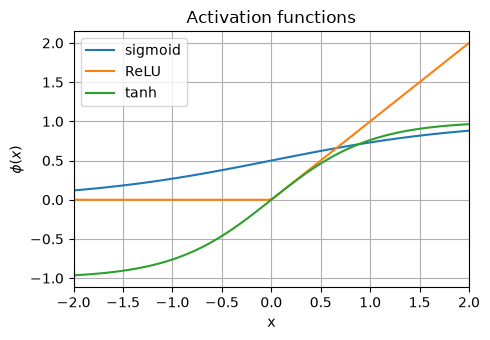

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 100)

def sigm(x):   # sigmoid
    return 1 / (1 + np.exp(-x))

def relu(x):   # rectified linear unit
    return np.maximum(x, 0)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, sigm(x), label='sigmoid')
ax.plot(x, relu(x), label='ReLU')
ax.plot(x, np.tanh(x), label='tanh')
ax.grid(True)
ax.legend()
ax.set_xlim([-2, 2])
ax.set_xlabel('x')
ax.set_ylabel(r'$\phi(x)$')
ax.set_title('Activation functions')
plt.tight_layout()

## 2. Typical MLP Structures

A **regression MLP** outputs scalar values. The number of output neurons equals the number of predicted values. To predict 2D geospatial coordinates, for example, you need 2 output neurons: latitude and longitude. For unbounded real outputs, the output layer has no activation. To constrain outputs, add an activation on the output layer: *ReLU* or *softplus* for strictly positive values, *sigmoid* or *tanh* for values bounded between 0 (or -1) and 1.

![Regression MLP](../img/MLPReg.png)

A **classification MLP** outputs one score per class. For binary problems, a single output neuron with a *sigmoid* gives the probability of the positive class. For multi-class problems, the output layer has one neuron per class and a *softmax* converts the scores into probabilities that sum to 1. In PyTorch, the model usually outputs the raw scores (called **logits**) and the loss function `nn.CrossEntropyLoss` applies the softmax internally.

![Classification MLP](../img/MLPClass.png)

## 3. Training Neural Networks

Training proceeds on small batches of data called **minibatches**.

The **forward pass** sends a minibatch from the input layer through the hidden layers to the output layer, computing and storing intermediate values along the way, and produces predictions.

The algorithm then measures the error with a **loss function**.

**Backpropagation** applies the chain rule backward through the network to compute the gradient of the loss with respect to every weight and bias. Because the chain rule needs the intermediate values from the forward pass, training requires more memory than prediction.

Finally, the **optimizer** (gradient descent or a variant such as Adam) updates the weights using these gradients. One pass through the full training set is called an **epoch**. Repeating this loop for many epochs gradually reduces the loss.

A **sequential** model is a single-branch MLP: data flows through the layers one after the other.

## 4. A Multi-Class MLP in PyTorch

We reuse the seismic-source dataset from notebook 4.1: 65 physical features extracted from seismograms of four source types (earthquakes, explosions, noise, surface events), 1000 events per class, from a Zenodo archive. In 4.1 we trained a shallow MLP. Here we build a deeper one with three hidden layers, dropout, and batch normalization.

In [2]:
import os
import pandas as pd
import pooch
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# device-agnostic setup: GPU if available, else Apple silicon, else CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


### 4.1 Load and clean the data

We download the four CSV files (one per source type) with `pooch`, concatenate them, and create an integer label from the class name. We drop the bookkeeping columns, drop one feature column that is entirely NaN, and remove any remaining rows with NaN or infinite values.

In [3]:
base = "https://zenodo.org/api/records/14025693/files"
class_files = {"earthquake": "1000_earthquakes_physical_features.csv",
               "explosion": "1000_explosion_physical_features.csv",
               "noise": "1000_noise_physical_features.csv",
               "surface event": "1000_surface_physical_features.csv"}

frames = []
for class_name, fname in class_files.items():
    path = pooch.retrieve(f"{base}/{fname}/content", known_hash=None, fname=fname)
    d = pd.read_csv(path)
    d["label"] = class_name
    frames.append(d)
df = pd.concat(frames, ignore_index=True)

# drop bookkeeping columns
df = df.drop(columns=["Unnamed: 0", "serial_no", "source"])

# clean: replace inf with NaN, drop all-NaN columns, then drop rows with NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=1, how="all").dropna()

class_names = list(class_files.keys())
y = df["label"].map({name: i for i, name in enumerate(class_names)}).to_numpy()
X = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
print(f"{X.shape[0]} samples, {X.shape[1]} features, {len(class_names)} classes")

4000 samples, 61 features, 4 classes


### 4.2 Split and scale

We hold out 20% of the data for the final test, and split the rest into training and validation sets. The validation set monitors overfitting during training; the test set is touched only once at the end. We standardize the features with `StandardScaler` fit on the **training set only**, so no information from the validation or test sets leaks into the preprocessing.

In [4]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval)

scaler = StandardScaler().fit(X_train)   # fit on train only
X_train = scaler.transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
print(f"train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}")

train: 2560, validation: 640, test: 800


### 4.3 Datasets and DataLoaders

PyTorch feeds data to the model through a `Dataset` (indexable storage of samples) and a `DataLoader` (batching and shuffling). Our arrays are already tensors-to-be, so `TensorDataset` is enough. We shuffle the training batches each epoch; the validation and test loaders do not need shuffling.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

### 4.4 A deeper MLP with dropout and batch normalization

The model has three hidden layers (128, 64, 32 units) instead of the single hidden layer of 4.1. Two new layer types appear:

**Dropout** (`nn.Dropout(p)`) randomly zeroes a fraction `p` of the activations at each training step and rescales the survivors by $1/(1-p)$. Because a neuron cannot rely on any particular other neuron being present, the network learns more redundant, general features, which reduces overfitting. Dropout is active only in training mode and is turned off at evaluation time.

**Batch normalization** (`nn.BatchNorm1d`) normalizes each unit's activations to zero mean and unit variance over the current minibatch, then applies a learned scale and shift. This keeps the activations in a stable range as the weights change, which stabilizes and speeds up training. At evaluation time it uses running estimates of the mean and variance collected during training.

Both layers behave differently in training and evaluation. Call `model.train()` before training and `model.eval()` before prediction to switch modes. The output layer returns raw logits; `nn.CrossEntropyLoss` will handle the softmax.

In [6]:
class SourceMLP(nn.Module):
    def __init__(self, n_features, n_classes, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, n_classes),   # logits, no activation
        )

    def forward(self, x):
        return self.net(x)

n_features, n_classes = X_train.shape[1], len(class_names)
model = SourceMLP(n_features, n_classes).to(device)
print(model)

SourceMLP(
  (net): Sequential(
    (0): Linear(in_features=61, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=4, bias=True)
  )
)


### 4.5 Training with minibatches and Adam

The training loop below follows the recipe of section 3: forward pass, loss, backpropagation, weight update, one minibatch at a time. We use the Adam optimizer, a variant of gradient descent with per-parameter adaptive learning rates (see the list of optimizers at https://pytorch.org/docs/stable/optim.html). After each epoch we evaluate the loss and accuracy on the validation set.

The loop also saves a **checkpoint** each time the validation loss improves. We come back to checkpoints in section 5; for now, note the `torch.save` call. Checkpoints go in a local `checkpoints/` directory.

We train for 40 epochs, which is enough for this small model. You can raise the number of epochs on your own machine.

In [7]:
def evaluate(model, loader, criterion):
    """Average loss and accuracy of the model over a DataLoader."""
    model.eval()   # evaluation mode: dropout off, batchnorm uses running stats
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():   # no gradients needed for evaluation
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n


def train(model, train_loader, val_loader, n_epochs=40, lr=1e-3,
          ckpt_path="checkpoints/best_mlp.pt"):
    os.makedirs("checkpoints", exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(n_epochs):
        model.train()   # training mode: dropout and batchnorm active
        running_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()             # reset gradients
            logits = model(xb)                # forward pass
            loss = criterion(logits, yb)      # loss
            loss.backward()                   # backpropagation
            optimizer.step()                  # weight update
            running_loss += loss.item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)

        history["train_loss"].append(running_loss / n)
        history["train_acc"].append(correct / n)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # checkpoint: save the model each time the validation loss improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({"epoch": epoch + 1,
                        "state_dict": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                        "val_loss": val_loss}, ckpt_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Epoch {epoch + 1:2d}] train loss: {history['train_loss'][-1]:.3f} "
                  f"- val loss: {val_loss:.3f} - val accuracy: {val_acc:.3f}")
    return history

In [8]:
history = train(model, train_loader, val_loader, n_epochs=40)

[Epoch  1] train loss: 1.042 - val loss: 0.724 - val accuracy: 0.809


[Epoch  5] train loss: 0.452 - val loss: 0.396 - val accuracy: 0.878


[Epoch 10] train loss: 0.353 - val loss: 0.346 - val accuracy: 0.895


[Epoch 15] train loss: 0.302 - val loss: 0.340 - val accuracy: 0.891


[Epoch 20] train loss: 0.273 - val loss: 0.334 - val accuracy: 0.886


[Epoch 25] train loss: 0.276 - val loss: 0.330 - val accuracy: 0.903


[Epoch 30] train loss: 0.246 - val loss: 0.326 - val accuracy: 0.891


[Epoch 35] train loss: 0.235 - val loss: 0.324 - val accuracy: 0.902


[Epoch 40] train loss: 0.217 - val loss: 0.327 - val accuracy: 0.908


### 4.6 Learning curves

We plot the training and validation loss side by side with the accuracies. The gap between the two curves is a direct read on overfitting: a training loss that keeps dropping while the validation loss stalls or rises means the model is memorizing the training set.

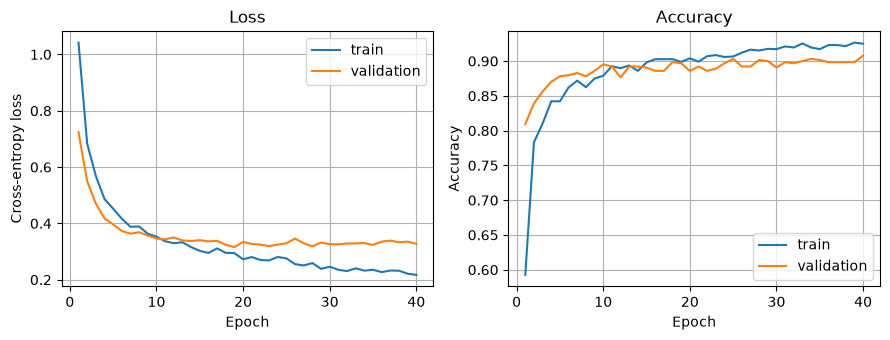

In [9]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["val_loss"], label="validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["val_acc"], label="validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True)
plt.tight_layout()

### 4.7 Test performance

We now evaluate once on the held-out test set: overall accuracy and per-class precision, recall, and F1 score.

In [10]:
def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(device))
            preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)

y_pred = predict(model, test_loader)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.890

               precision    recall  f1-score   support

   earthquake       0.90      0.85      0.88       200
    explosion       0.86      0.81      0.83       200
        noise       0.90      0.96      0.93       200
surface event       0.90      0.94      0.92       200

     accuracy                           0.89       800
    macro avg       0.89      0.89      0.89       800
 weighted avg       0.89      0.89      0.89       800



**Exercise**: rebuild the model with `p_drop=0.0` and retrain. How does the gap between the training and validation curves change?

```{admonition} Solution
:class: dropdown
Run `model_nodrop = SourceMLP(n_features, n_classes, p_drop=0.0).to(device)` and call `train` on it. Without dropout, the training loss drops faster and further, and the training accuracy climbs higher, but the validation curves stall earlier: the gap between the two widens. That widening gap is overfitting, which dropout was suppressing.
```

## 5. Saving and Restoring a Model

### 5.1 Saving weights with `state_dict`

A PyTorch model's learnable parameters live in its `state_dict`, a dictionary that maps each layer to its weight and bias tensors. The standard way to save a trained model is to save this dictionary, not the model object itself:

1. `torch.save(model.state_dict(), path)` writes the weights to disk.
2. To restore, build a fresh instance of the same model class and call `load_state_dict`.
3. Call `model.eval()` before prediction, so dropout is off and batchnorm uses its running statistics.

Loading with `map_location=device` makes the file portable across machines: weights saved on a GPU load fine on a CPU-only machine.

In [11]:
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/mlp_weights.pt")

# restore into a fresh model instance
restored = SourceMLP(n_features, n_classes).to(device)
restored.load_state_dict(torch.load("checkpoints/mlp_weights.pt", map_location=device))
restored.eval()

# check that the restored model gives the same predictions
y_pred_restored = predict(restored, test_loader)
print(f"Restored predictions identical: {np.array_equal(y_pred, y_pred_restored)}")

Restored predictions identical: True


### 5.2 Checkpointing during training

Saving only the final weights has a flaw: the last epoch is not always the best one. If the model starts to overfit, the validation loss rises while training continues, and the final weights are worse than an earlier version. **Checkpointing** fixes this: during training we saved the model every time the validation loss improved (section 4.5), together with the epoch number and the optimizer state. The optimizer state lets you resume training exactly where the checkpoint was taken.

We now restore the best checkpoint and evaluate it on the test set.

In [12]:
ckpt = torch.load("checkpoints/best_mlp.pt", map_location=device)
print(f"Best checkpoint: epoch {ckpt['epoch']}, validation loss {ckpt['val_loss']:.3f}")

best_model = SourceMLP(n_features, n_classes).to(device)
best_model.load_state_dict(ckpt["state_dict"])
best_model.eval()

y_pred_best = predict(best_model, test_loader)
print(f"Test accuracy (final model): {accuracy_score(y_test, y_pred):.3f}")
print(f"Test accuracy (best checkpoint): {accuracy_score(y_test, y_pred_best):.3f}\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))

Best checkpoint: epoch 19, validation loss 0.316
Test accuracy (final model): 0.890
Test accuracy (best checkpoint): 0.886

               precision    recall  f1-score   support

   earthquake       0.89      0.85      0.87       200
    explosion       0.86      0.82      0.84       200
        noise       0.90      0.93      0.92       200
surface event       0.89      0.94      0.91       200

     accuracy                           0.89       800
    macro avg       0.89      0.89      0.89       800
 weighted avg       0.89      0.89      0.89       800



## 6. MLP in scikit-learn

Scikit-learn ships its own MLP, `MLPClassifier` (and `MLPRegressor`). It is the same model family: fully connected layers, ReLU activations, minibatch training with Adam. The trade-off is control. You give up the custom training loop, dropout, batch normalization, checkpointing, and GPU execution, and in exchange the whole workflow is a few lines that fit the familiar `fit`/`predict` interface. For small tabular problems this is often all you need.

We demonstrate on the synthetic event-detector features from `mlgeo_synth`: 4 waveform-derived features (STA/LTA, kurtosis, spectral centroid, dominant frequency) and a balanced binary label (event vs. noise).

In [13]:
from mlgeo_synth import detector_features
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

det = detector_features(n=2000, event_fraction=0.5, seed=0)
X_det = det.drop(columns=["label"]).to_numpy()
y_det = det["label"].to_numpy()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_det, y_det, test_size=0.2, random_state=42, stratify=y_det)

clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42))
clf.fit(Xd_train, yd_train)
print(f"Train accuracy: {clf.score(Xd_train, yd_train):.3f}")
print(f"Test accuracy:  {clf.score(Xd_test, yd_test):.3f}")
print(classification_report(yd_test, clf.predict(Xd_test),
                            target_names=["noise", "event"]))

Train accuracy: 0.991
Test accuracy:  0.985
              precision    recall  f1-score   support

       noise       0.97      1.00      0.99       200
       event       1.00      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



Two lines of model code, no training loop, and the pipeline handles the scaling. But the architecture choices stop at layer sizes, activation, and a handful of solver settings. When you need dropout, batch normalization, custom losses, or a GPU, you write the PyTorch version.

## 7. Summary

In this notebook you:
* reviewed activation functions and the structure of regression and classification MLPs,
* built a three-hidden-layer MLP with dropout and batch normalization in PyTorch and trained it with minibatches and Adam on the four-class seismic-source data,
* read overfitting off the train/validation learning curves,
* saved and restored models with `state_dict`, and used checkpoints to keep the best version seen during training,
* compared with scikit-learn's `MLPClassifier`.

We picked the layer sizes, dropout rate, and learning rate here by hand. Choosing them systematically, by searching over architectures and hyperparameters, is the subject of the lab in notebook 4.5.